# Examen blanc - ML - FitNation

In [6]:
# Importation des bibliothèques
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import mean_squared_error,r2_score
import statsmodels.api as sm

## Analyse exploratoire & préparation des données - Modèle 1

In [10]:
df = pd.read_csv(r"C:\Users\Amen\Desktop\DATA ANALYST\Module 5 - Machine Learning\Jour - 06\INPUT\clients_2018_2023.csv")

In [13]:
# Informations générales 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id_client            10000 non-null  int64  
 1   age                  9990 non-null   float64
 2   anciennete_mois      10000 non-null  int64  
 3   nb_seances_moy_mois  9990 non-null   float64
 4   abonnement_premium   10000 non-null  int64  
 5   coaching             10000 non-null  int64  
 6   satisfaction         9990 non-null   float64
 7   revenu_mensuel       9990 non-null   float64
 8   churn                10000 non-null  int64  
dtypes: float64(4), int64(5)
memory usage: 703.3 KB


Le fichier contient 10000 lignes et 8 colonnes. Il y a 4 colonnes avec 10 valeurs manquantes. Les types de données dans ce fichier sont des float64 (valeurs décimales) et int64 (valeurs entières).

In [22]:
df.head()

,id_client,age,anciennete_mois,nb_seances_moy_mois,abonnement_premium,coaching,satisfaction,revenu_mensuel,churn
0,1,42.0,31,2.7,0,1,4.8,61.29,0
1,2,36.0,53,5.9,1,0,6.1,74.91,0
2,3,44.0,34,2.9,0,1,5.2,59.89,0
3,4,53.0,38,5.4,0,0,7.4,54.76,0
4,5,35.0,57,5.0,0,1,8.9,60.95,0


In [16]:
# Affichage des statistiques et détection d'eventuelles valeurs aberrantes
df.describe().round(2)

,id_client,age,anciennete_mois,nb_seances_moy_mois,abonnement_premium,coaching,satisfaction,revenu_mensuel,churn
count,10000.00,9990.00,10000.00,9990.00,10000.00,10000.00,9990.00,9990.00,10000.00
mean,5000.50,37.58,36.35,5.04,0.39,0.25,5.70,70.07,0.06
std,2886.90,9.86,20.83,2.20,0.49,0.43,2.06,22.56,0.24
min,1.00,18.00,1.00,0.50,0.00,0.00,0.00,20.00,0.00
25%,2500.75,31.00,18.00,3.60,0.00,0.00,4.30,54.97,0.00
50%,5000.50,37.00,36.00,5.00,0.00,0.00,5.70,69.00,0.00
75%,7500.25,44.00,54.00,6.40,1.00,0.00,7.10,84.23,0.00
max,10000.00,150.00,72.00,100.00,1.00,1.00,10.00,999.00,1.00


**id_client** : Il y a 10000 clients.

**age** : La moyenne d'âge est de 37,58 ans et les plus jeunes ont 18 ans.

**anciennete_mois** : 25 % des clients ont une ancienneté de 18 mois et 75 % ont une ancienneté de 54 mois.

**nb_seances_moy_mois** : La médiane sur le nombre de fréquentation moyenne par mois est de 5 ce qui est peu. 

**abonnement_prenium** : La moyenne est d'environ 39 %. Les clients ne sont pas intéressés par l'offre prenium. Variable binaire (0 ou 1)

**coaching** : La moyenne est de 25 %. Les clients ne demandent pas souvent à être suivis par des coachs. Variable binaire (0 ou 1)

**satisfaction** : Echelle entre 0 à 10. Le minimum de satisfaction est de 0 et la maximum est de 10.

**revenu_mensuel** : La moyenne est 70,07 €.

**Churn** : Valeur binaire. La moyenne est de 6 %. Ce qui est relativement faible.

In [32]:
# Valeurs manquantes 
print("\nValeurs manquantes dans les données du modèle 1 :")
df.isnull().sum()


Valeurs manquantes dans les données du modèle 1 :


id_client               0
age                    10
anciennete_mois         0
nb_seances_moy_mois    10
abonnement_premium      0
coaching                0
satisfaction           10
revenu_mensuel         10
churn                   0
dtype: int64

Nous allons remplacer les valeurs manquantes par la médiane pour l'imputation. C'est une méthode simple et robuste qui ne devrait pas affecter significativement les résultats.

In [37]:
# Création d'une copie 
df_clean = df.copy()

# Remplacer toutes les valeurs manquantes numériques par leur médiane respective
df_clean = df_clean.fillna(df_clean.median())

# Vérification
print("Valeurs manquantes après traitement :")
print(df_clean.isnull().sum())



Valeurs manquantes après traitement :
id_client              0
age                    0
anciennete_mois        0
nb_seances_moy_mois    0
abonnement_premium     0
coaching               0
satisfaction           0
revenu_mensuel         0
churn                  0
dtype: int64


## Vérification des valeurs aberrantes avec les graphiques moustaches

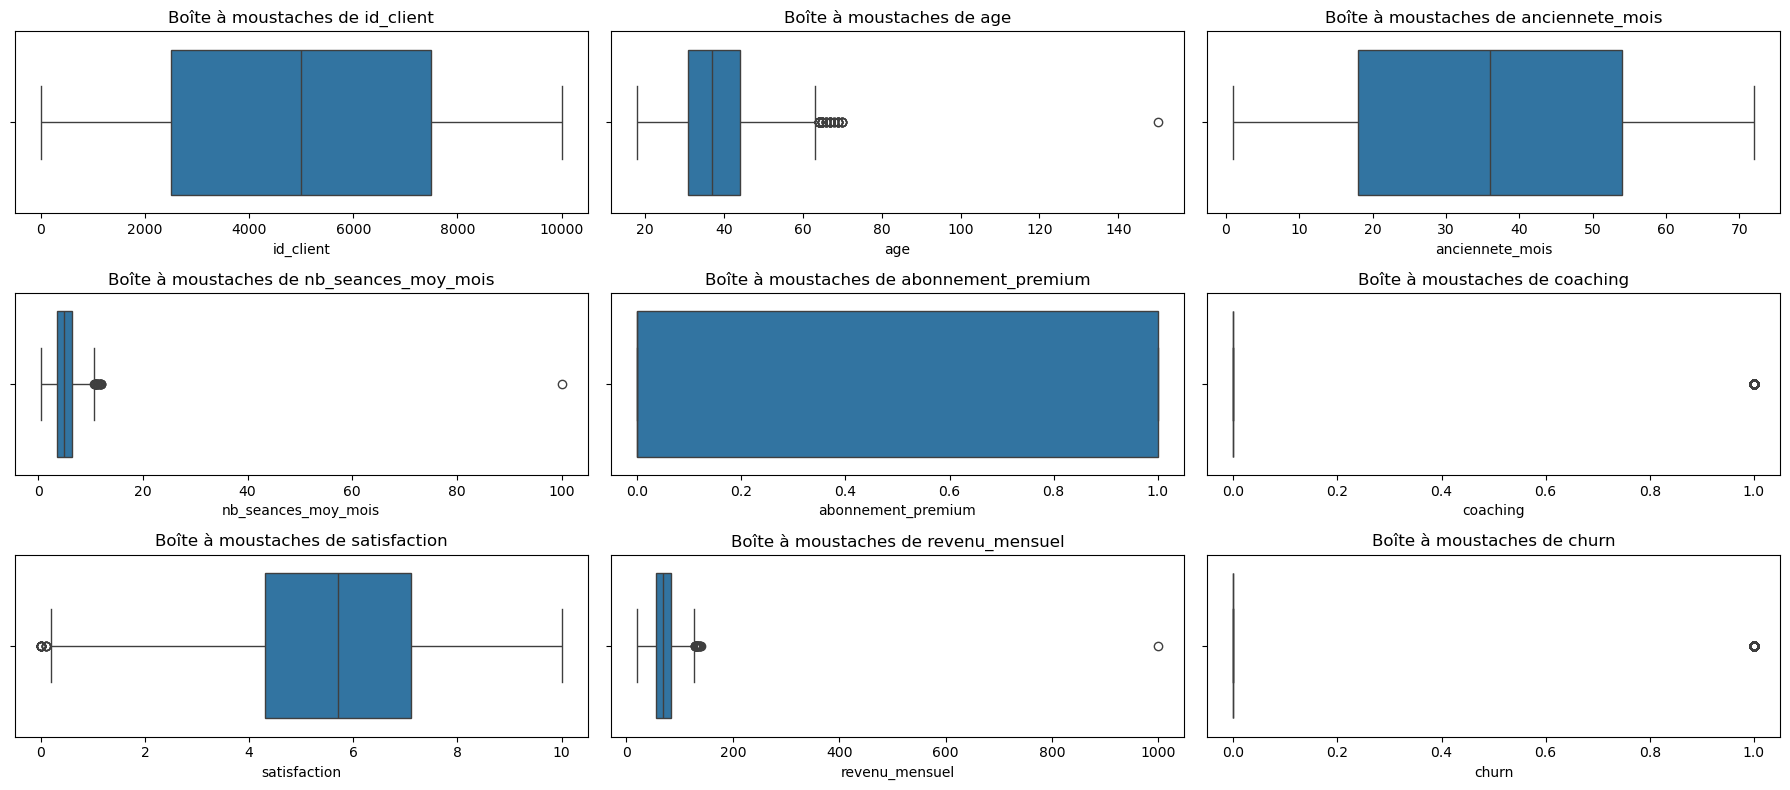

In [46]:
# Crée une figure avec 3 lignes et 3 colonnes
fig, axes = plt.subplots(3, 3, figsize=(18, 8))  # 3 rangées, 3 colonnes, grande taille pour mieux voir

# Liste des 9 colonnes à tracer
cols = df_clean.select_dtypes(include=['float64', 'int64']).columns

# Boucle sur les colonnes et les axes 
for ax, col in zip(axes.flatten(), cols):
    sns.boxplot(x=df_clean[col], ax=ax)  # Trace le boxplot dans l'axe correspondant
    ax.set_title(f'Boîte à moustaches de {col}')  # Met un titre avec le nom de la colonne

plt.tight_layout()  # Ajuste bien l'espace entre les graphiques
plt.show()  # Affiche le tout

**Analyse des boxplots** :

1. *ID client*
Distribution uniforme des IDs (normal pour un identifiant)

2. *Âge*
Majorité entre 30-45 ans
Quelques outliers au-delà de 80 ans.
Une valeur aberrante qui est l'âge de 150 à traiter.

4. *Ancienneté*
La plupart des clients ont une ancienneté entre 20-50 mois
Quelques outliers avec plus de 60 mois d'ancienneté

4. *Nombre de séances moyennes/mois*
La plupart des clients ont un nombre de séances entre 3 à 7.
Outliers importants à 100 séances à traiter.

5. *Abonnement premium* et *Coaching*
Ce sont des variables binaires (0 ou 1).

6. *Satisfaction*
Distribution autour de 5-7/10.
Quelques clients très insatisfaits (0) ou très satisfaits (10).

7. *Revenu mensuel*
Majorité entre 50-90€.
Outliers importants à 1000€ à traiter.

8. *Churn*
Variable binaire (0=actif, 1=résilié)

> Présence d'outliers significatifs pour : âge de 150 ans, nombre de séances de 100 par mois et un revenu mensuel de 1000€.
Ces valeurs extrêmes nécessitent un traitement avant la modélisation.
Les variables binaires (abonnement_premium, coaching, churn) n'ont pas besoin de traitement particulier.

## Nettoyage et Préparation des données

In [55]:
# Méthode de l'IQR (Interquartile Range) pour détecter les outliers
def detect_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df_clean[(df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)]
    return outliers, lower_bound, upper_bound

In [71]:
# Détection des outliers pour chaque variable
for col in ["age", "anciennete_mois", "nb_seances_moy_mois", "satisfaction", "revenu_mensuel", "churn"]:
    outliers, lower, upper = detect_outliers(df_clean, col)
    print(f"\nOutliers pour {col}:")
    print(f"Nombre d'outliers: {len(outliers)}")
    print(f"Limite inférieure: {lower:.2f}, Limite supérieure: {upper:.2f}")
    if not outliers.empty:
        print("Exemples d'outliers:")
        print(outliers[col].head())


Outliers pour age:
Nombre d'outliers: 50
Limite inférieure: 11.50, Limite supérieure: 63.50
Exemples d'outliers:
179      65.0
209      70.0
478      68.0
755      64.0
1260    150.0
Name: age, dtype: float64

Outliers pour anciennete_mois:
Nombre d'outliers: 0
Limite inférieure: -36.00, Limite supérieure: 108.00

Outliers pour nb_seances_moy_mois:
Nombre d'outliers: 23
Limite inférieure: -0.60, Limite supérieure: 10.60
Exemples d'outliers:
947     11.3
1434    11.2
1765    11.8
2398    11.6
2664    10.8
Name: nb_seances_moy_mois, dtype: float64

Outliers pour satisfaction:
Nombre d'outliers: 21
Limite inférieure: 0.10, Limite supérieure: 11.30
Exemples d'outliers:
129     0.1
1154    0.0
1223    0.0
1525    0.1
1733    0.0
Name: satisfaction, dtype: float64

Outliers pour revenu_mensuel:
Nombre d'outliers: 24
Limite inférieure: 11.16, Limite supérieure: 128.05
Exemples d'outliers:
47      129.14
1196    131.27
1384    131.10
1765    128.67
1897    129.95
Name: revenu_mensuel, dtype: 

In [74]:
# Suppression des outliers identifiés
df_clean_final = df_clean[~(
    (df_clean["age"] > 63.50) | 
    (df_clean["nb_seances_moy_mois"] > 10.60) | 
    (df_clean["satisfaction"] < 0.10) | 
    (df_clean["revenu_mensuel"] > 128.05)
)]

# Vérification du nombre d'observations avant et après
print(f"Nombre d'observations avant suppression: {len(df_clean)}")
print(f"Nombre d'observations après suppression: {len(df_clean_final)}")
print(f"Nombre d'observations supprimées: {len(df_clean) - len(df_clean_final)}")

Nombre d'observations avant suppression: 10000
Nombre d'observations après suppression: 9890
Nombre d'observations supprimées: 110


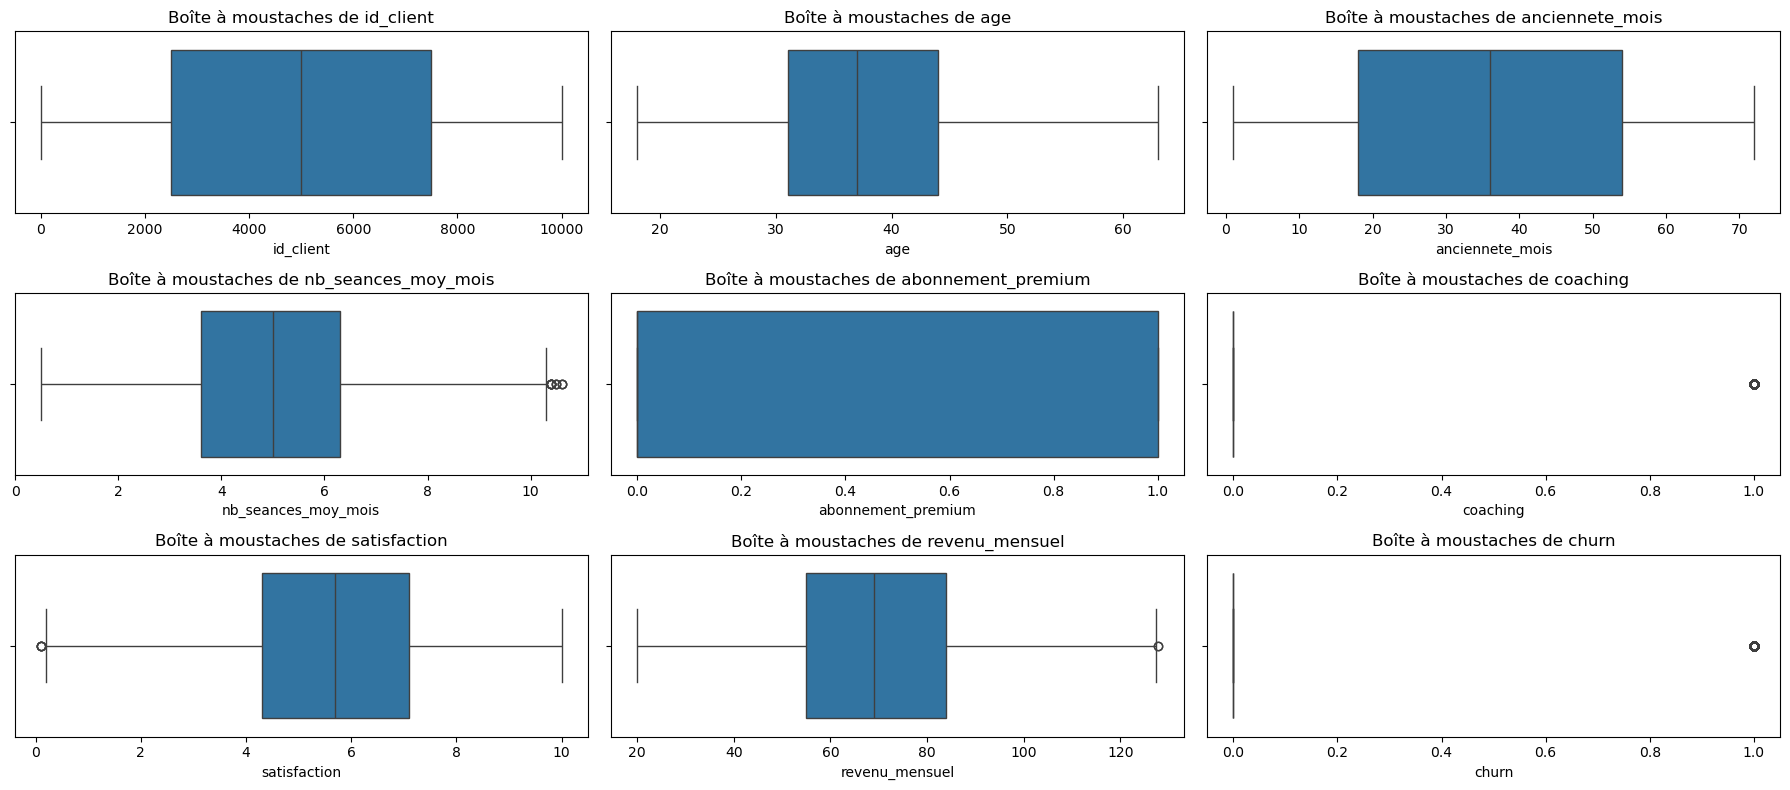

In [79]:
# Vérification des suppressions

# Crée une figure avec 3 lignes et 3 colonnes
fig, axes = plt.subplots(3, 3, figsize=(18, 8))  # 3 rangées, 3 colonnes, grande taille pour mieux voir

# Liste des 9 colonnes à tracer
cols = df_clean_final.select_dtypes(include=['float64', 'int64']).columns

# Boucle sur les colonnes et les axes 
for ax, col in zip(axes.flatten(), cols):
    sns.boxplot(x=df_clean_final[col], ax=ax)  # Trace le boxplot dans l'axe correspondant
    ax.set_title(f'Boîte à moustaches de {col}')  # Met un titre avec le nom de la colonne

plt.tight_layout()  # Ajuste bien l'espace entre les graphiques
plt.show()  # Affiche le tout

## Analyse et Modélisation

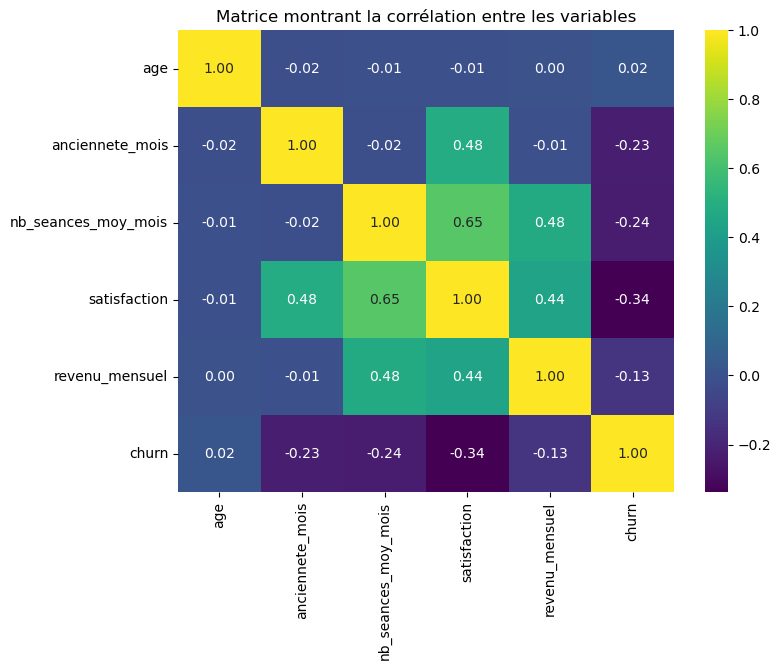

In [86]:
# Calcul de la matrice de corrélation
correlation = df_clean_final[["age", "anciennete_mois", "nb_seances_moy_mois", "satisfaction", "revenu_mensuel", "churn"]].corr()

# Création de la heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap='viridis', fmt=".2f")
plt.title('Matrice montrant la corrélation entre les variables')
plt.show()

***INTERPRÉTATION DE LA MATRICE DE CORRÉLATION***

* **Satisfaction et nb_seances_moy_mois (0.65)** :
Les clients qui fréquentent plus régulièrement le club sont plus satisfaits.
Relation très positive : plus de séances = meilleure satisfaction.

* **Anciennete_mois et satisfaction (0.48)** :
Les clients plus anciens sont généralement plus satisfaits.
La fidélité semble être liée à la satisfaction.

* **Nb_seances_moy_mois et revenu_mensuel (0.48)** :
Les clients qui viennent plus souvent génèrent plus de revenus.

* **Satisfaction et revenu_mensuel (0.44)** :
Les clients satisfaits dépensent plus.
La satisfaction client se montre par un revenu plus élevé.

Relations négatives importantes :

* **Satisfaction et churn (-0.34)** :
Les clients insatisfaits ont plus tendance à résilier
Confirme l'importance de la satisfaction pour la rétention

* **Anciennete_mois et churn (-0.23)** :
Les clients plus anciens ont moins tendance à résilier
La fidélité réduit le risque de churn

* **Nb_seances_moy_mois et churn (-0.24)** :
Les clients qui fréquentent régulièrement ont moins tendance à résilier.
L'engagement réduit le risque de churn.


*la modélisation :*

Pour prédire le revenu_mensuel, les variables les plus importantes seront :

nb_seances_moy_mois, 
satisfaction, 
anciennete_mois,


Pour prédire le churn, les variables clés seront :

satisfaction (relation négative forte),
nb_seances_moy_mois (relation négative),
anciennete_mois (relation négative).

## Séparation des variables features et target. Création du modèle d'entrainement

In [103]:
# Séparation des variables features (X) et de la variable target (Y)
X = df_clean_final.drop(["id_client", "revenu_mensuel", "churn"], axis=1)
y = df_clean_final["revenu_mensuel"]

# Séparation en ensemble d'entraînement et ensemble de test avec un ratio de 20%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [108]:
# Construction du modèle de régression linéaire multiple grâce à la base sklearn
model = LinearRegression()

# Entraînement du modèle 
model.fit(X_train, y_train)

# Calcul de prédiction
y_pred = model.predict(X_test)

## Détermination des coefficients de correlation et de détermination

In [116]:
# Calcul des coefficients de correlation (RMSE) et de détermination (R²)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'MSE: {mse}')
print(f'R²: {r2}')

MSE: 102.4091415598736
R²: 0.7477170585840232


* Le coefficient de détermination indique que le modèle explique la variabilité du revenu_mensuel à hauteur de 75 %.
* MSE faible = faible erreur de prediction.

## Coef des différentes variables et leurs incidences

In [123]:
# Calcul de l'intercept
print(f'Intercept: {model.intercept_}')

# Affichage des coefficients pour chaque variable
coef = pd.DataFrame(model.coef_, X.columns, columns=["Coefficient"])
print(coef)

Intercept: 29.832524852661244
                     Coefficient
age                     0.019801
anciennete_mois        -0.017643
nb_seances_moy_mois     4.876869
abonnement_premium     24.735071
coaching               19.214531
satisfaction            0.166526


**Analyse des coefficients**
Intercept : 29.83
C'est le revenu mensuel de base quelque soit les autres valeurs, c'est le prix minimum d'un abonnement.

**Coefficients :**
* abonnement_premium : 24.74
Impact le plus fort : un client avec abonnement premium génère 24,74€ de plus par mois.
* coaching : 19.21
Les clients qui utilisent le coaching apportent 19,21€ de plus par mois.
* nb_seances_moy_mois : 4.88
Chaque séance supplémentaire par mois augmente le revenu de 4,88€.
* satisfaction : 0.17
Chaque point de satisfaction supplémentaire augmente le revenu de 0,17€.
* age : 0.02
Les clients plus âgés dépensent légèrement plus
* anciennete_mois : -0.02
Les clients plus anciens dépensent un peu moins

## Interprétation métier 

* L'abonnement premium est le facteur le plus important pour augmenter le revenu
* Les services additionnels (coaching) sont très rentables
* La fréquentation régulière génère des revenus supplémentaires
* La satisfaction client a un impact positif mais modéré
* L'âge a peu d'influence
* Les clients plus anciens dépensent légèrement moins (possibles remises fidélité)

## Analyse exploratoire & préparation des données - Modèle 2

In [132]:
clients = pd.read_csv(r"C:\Users\Amen\Desktop\DATA ANALYST\Module 5 - Machine Learning\Jour - 06\INPUT\clients_2024.csv")
clients.head()

,id_client,age,anciennete_mois,nb_seances_moy_mois,abonnement_premium,coaching,satisfaction
0,10001,31,12,5.9,1,0,3.6
1,10002,36,2,6.3,0,1,4.0
2,10003,23,6,8.4,0,0,3.4
3,10004,24,11,3.2,1,0,2.0
4,10005,41,3,3.2,0,0,2.7


In [135]:
clients.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id_client            2000 non-null   int64  
 1   age                  2000 non-null   int64  
 2   anciennete_mois      2000 non-null   int64  
 3   nb_seances_moy_mois  2000 non-null   float64
 4   abonnement_premium   2000 non-null   int64  
 5   coaching             2000 non-null   int64  
 6   satisfaction         2000 non-null   float64
dtypes: float64(2), int64(5)
memory usage: 109.5 KB


Le fichier contient 2000 lignes et 7 colonnes. Pas de valeurs manquantes. 

In [138]:
clients.describe().round(2)

,id_client,age,anciennete_mois,nb_seances_moy_mois,abonnement_premium,coaching,satisfaction
count,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00
mean,11000.50,37.64,8.15,4.95,0.40,0.26,3.03
std,577.49,9.66,4.46,1.95,0.49,0.44,1.52
min,10001.00,18.00,1.00,0.50,0.00,0.00,0.00
25%,10500.75,31.00,4.00,3.60,0.00,0.00,1.90
50%,11000.50,38.00,8.00,4.90,0.00,0.00,3.00
75%,11500.25,44.25,12.00,6.30,1.00,1.00,4.00
max,12000.00,68.00,15.00,11.40,1.00,1.00,7.80


* id_client : Il y a 2000 clients.
* age : l'âge est entre 18 et 68 ans.
* anciennete_mois : Le maximum est de 15 mois et la moyenne est d'environ 8 mois.
* nb_seances_moy_mois : La médiane est d'environ 5 seances par mois.
* abonnement_premium : La moyenne est de 40 %.
* coaching : La moyenne est 26 %, ce qui est faible.
* satisfaction : La satisfaction des clients tournent autour de 0 à 7,8 sur 10.

## Valeurs aberrantes 

In [146]:
# Méthode de l'IQR (Interquartile Range) pour détecter les outliers
def detect_outliers(clients, col):
    Q1 = clients[col].quantile(0.25)
    Q3 = clients[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = clients[(clients[col] < lower_bound) | (clients[col] > upper_bound)]
    return outliers, lower_bound, upper_bound

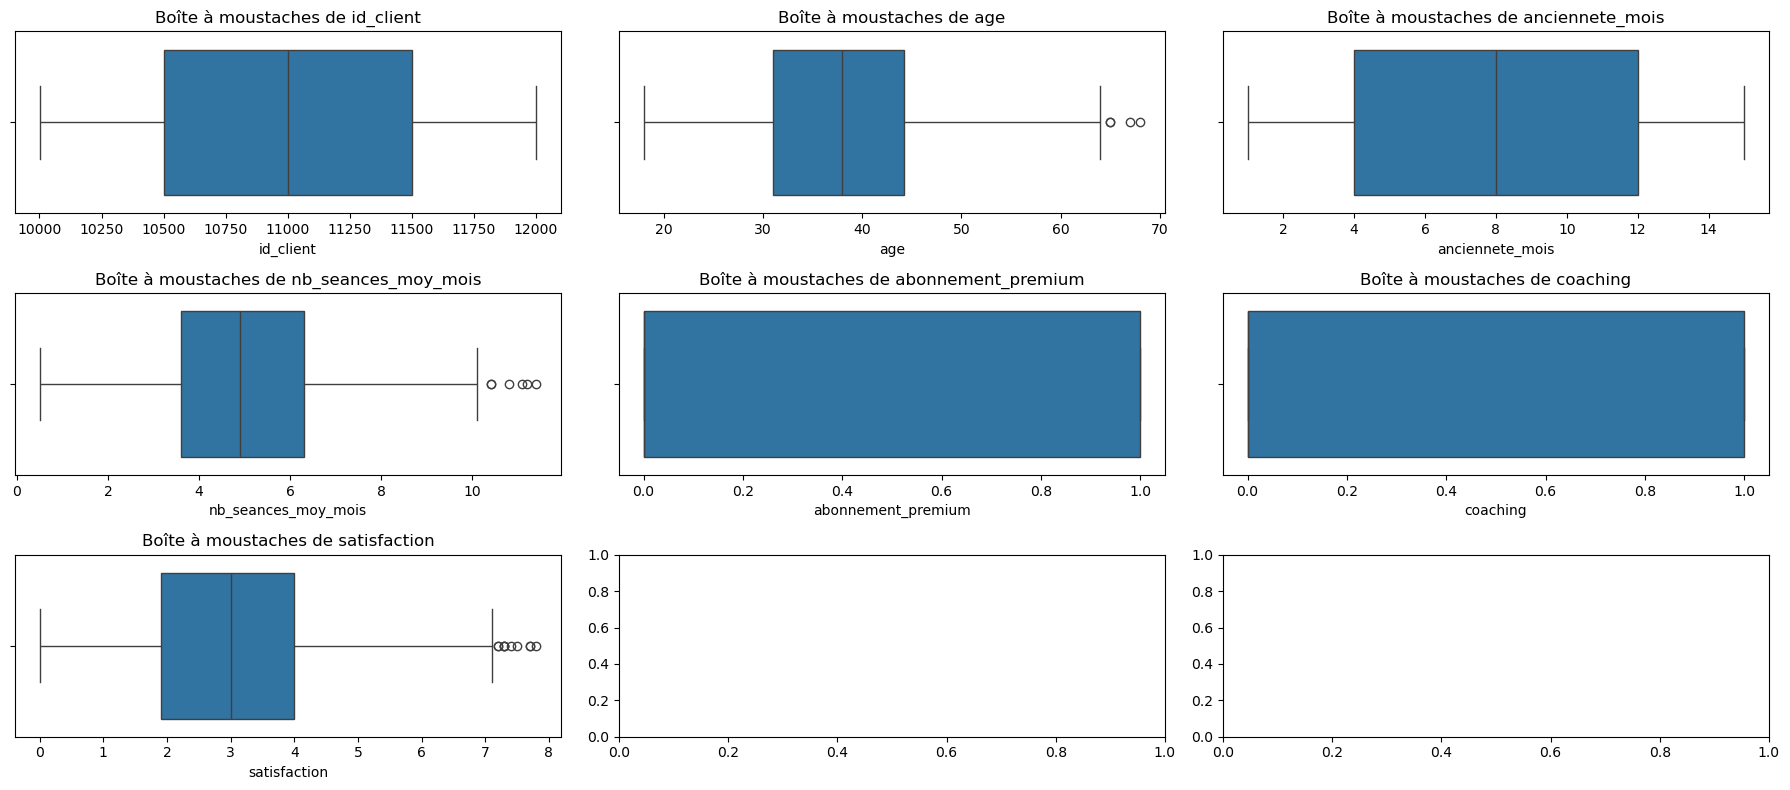

In [156]:
# Crée une figure 
fig, axes = plt.subplots(3, 3, figsize=(18, 8))  

# Liste des 7 colonnes à tracer
cols = clients.select_dtypes(include=['float64', 'int64']).columns

# Boucle sur les colonnes et les axes 
for ax, col in zip(axes.flatten(), cols):
    sns.boxplot(x=clients[col], ax=ax)  
    ax.set_title(f'Boîte à moustaches de {col}')  

plt.tight_layout()  # Ajuste bien l'espace entre les graphiques
plt.show()  # Affiche le tout

In [158]:
# Détection des outliers pour chaque variable
for col in ["age", "anciennete_mois", "nb_seances_moy_mois", "satisfaction"]:
    outliers, lower, upper = detect_outliers(clients, col)
    print(f"\nOutliers pour {col}:")
    print(f"Nombre d'outliers: {len(outliers)}")
    print(f"Limite inférieure: {lower:.2f}, Limite supérieure: {upper:.2f}")
    if not outliers.empty:
        print("Exemples d'outliers:")
        print(outliers[col].head())


Outliers pour age:
Nombre d'outliers: 4
Limite inférieure: 11.12, Limite supérieure: 64.12
Exemples d'outliers:
768     65
896     67
1045    65
1883    68
Name: age, dtype: int64

Outliers pour anciennete_mois:
Nombre d'outliers: 0
Limite inférieure: -8.00, Limite supérieure: 24.00

Outliers pour nb_seances_moy_mois:
Nombre d'outliers: 6
Limite inférieure: -0.45, Limite supérieure: 10.35
Exemples d'outliers:
208     10.4
500     10.4
525     11.1
992     11.2
1386    10.8
Name: nb_seances_moy_mois, dtype: float64

Outliers pour satisfaction:
Nombre d'outliers: 10
Limite inférieure: -1.25, Limite supérieure: 7.15
Exemples d'outliers:
5      7.3
214    7.7
613    7.5
823    7.3
827    7.2
Name: satisfaction, dtype: float64


Outliers détectés :

* Age : 4 outliers (65-68 ans)
Ces valeurs sont raisonnables, il y a quelques clients d'un certain âge.
Pas besoin de traitement spécial.
* Nombre de séances par mois : 6 outliers (10.4 à 11.2 séances).
Ces valeurs sont possibles (environ 3 séances par semaine).
* Satisfaction : 10 outliers (7.2-7.7)
Ce sont des scores de satisfaction élevés mais possible. Ces clients très satisfaits sont importants pour l'analyse.

## Préparation des données 

In [164]:
# Séparation X / y
X = df_clean_final.drop(columns=["churn"])
y = df_clean_final["churn"]

# Split train/test pour évaluer les performances
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Construction du modèle 

In [169]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [172]:
predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)
print(f"Précision du modèle : {accuracy * 100:.2f}%")

conf_matrix = confusion_matrix(y_test, predictions)
print("Matrice de confusion :")
print(conf_matrix)

Précision du modèle : 94.03%
Matrice de confusion :
[[1839   12]
 [ 106   21]]


## Résultat global

* Précision globale du modèle : 94,03 %
  Cela signifie que le modèle fait une très bonne prédiction pour environ 9 clients sur 10.

Un score supérieur de 90 % est très satisfaisant pour une première approche.

## Matrice de confusion 

|                 | Prédit : Client resté (0) | Prédit : Client churné (1) |
|:----------------|:-------------------------|:---------------------------|
| **Réel : Client resté (0)** | 1839 | 12 |
| **Réel : Client churné (1)** | 106 | 21 |

##  Analyse de la matrice de confusion

- **Vrais positifs (churn correctement détecté)** : 21 clients.
- **Vrais négatifs (clients fidèles correctement détectés)** : 1839 clients.
- **Faux positifs (prédit comme churn alors qu'il reste)** : 12 clients.
- **Faux négatifs (prédit comme restant alors qu'il churn)** : 106 clients.

## Fonction de prédiction personnalisée

In [191]:
# Création de la colonne manquante dans la dataframe clients
clients["revenu_mensuel"] = df_clean_final["revenu_mensuel"].mean()

In [193]:
# Réordonné les colonnes 
clients_corrige = clients[X.columns]

In [196]:
y_pred_2024 = model.predict(clients_corrige)
y_proba_2024 = model.predict_proba(clients_corrige)[:, 1]

In [199]:
clients_corrige.head()

,id_client,age,anciennete_mois,nb_seances_moy_mois,abonnement_premium,coaching,satisfaction,revenu_mensuel
0,10001,31,12,5.9,1,0,3.6,69.791317
1,10002,36,2,6.3,0,1,4.0,69.791317
2,10003,23,6,8.4,0,0,3.4,69.791317
3,10004,24,11,3.2,1,0,2.0,69.791317
4,10005,41,3,3.2,0,0,2.7,69.791317


In [201]:
# Construction du dataframe final
resultats = clients.copy()
resultats["prediction_churn"] = y_pred_2024
resultats["probabilite_churn"] = y_proba_2024

In [205]:
print(resultats.columns)
resultats.head()

Index(['id_client', 'age', 'anciennete_mois', 'nb_seances_moy_mois',
       'abonnement_premium', 'coaching', 'satisfaction', 'revenu_mensuel',
       'prediction_churn', 'probabilite_churn'],
      dtype='object')


,id_client,age,anciennete_mois,nb_seances_moy_mois,abonnement_premium,coaching,satisfaction,revenu_mensuel,prediction_churn,probabilite_churn
0,10001,31,12,5.9,1,0,3.6,69.791317,0,0.102891
1,10002,36,2,6.3,0,1,4.0,69.791317,0,0.095313
2,10003,23,6,8.4,0,0,3.4,69.791317,0,0.050027
3,10004,24,11,3.2,1,0,2.0,69.791317,0,0.367627
4,10005,41,3,3.2,0,0,2.7,69.791317,0,0.318863


In [208]:
resultats.to_csv("predictions_churn_2024_Amen_BOUMEDIENE.csv", index=False)